In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

In [2]:
from qgan_lamarr import QGAN, MinMaxBinning, SingleGaussian

2026-05-06 09:55:11.677726: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 09:55:11.692340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778054111.709076   41165 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778054111.713855   41165 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778054111.730646   41165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Distribution embedding

{'000': 34, '001': 144, '010': 266, '011': 282, '100': 208, '101': 64, '110': 23, '111': 3}


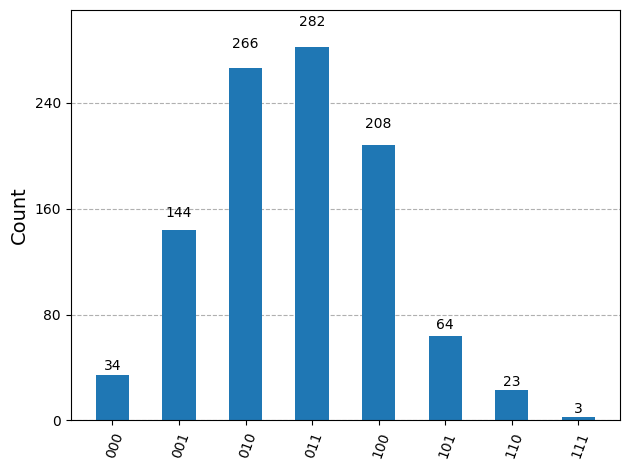

In [3]:
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _sample = SingleGaussian(shots = _size)
    return MinMaxBinning(_sample, _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN evaluation

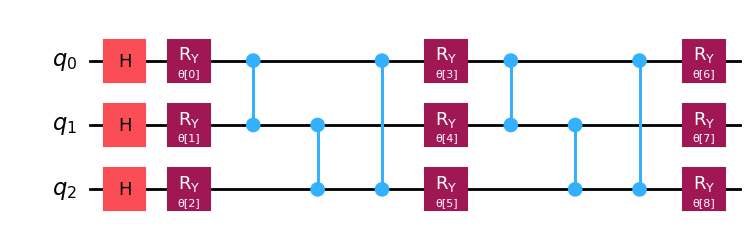

In [4]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)

p = 0

for q in range(num_qubits):
        qc.ry(theta[q], q)
        p += 1
for r in range(reps):

    for q in range(num_qubits):
        qc.cz(q%num_qubits, (q + 1)%num_qubits)
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1
        
    

qc.draw("mpl")

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='linear') 
])

discriminator.summary()

2026-05-06 02:34:40.012750: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 02:34:40.026065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778027680.041327  115887 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778027680.045600  115887 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778027680.063664  115887 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

NameError: name 'nbins' is not defined

In [6]:
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist,
             wass = True)

In [ ]:
epochs = 2000
model.discriminator_lr = 1e-4
model.fit(epochs = epochs, shots = 2**10, step_balance = 5.0, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260506_023331
Training started


 11%|█         | 224/2000 [01:01<08:02,  3.68it/s]

In [ ]:
baseline_js, baseline_js_std = model.compute_baseline_js(n_samples = 100)
print(f"Sampling Noise Floor (JS Baseline): {baseline_js:.4f}({baseline_js_std:.4f})")

In [ ]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.plot(model.metrics['jensen_shannon'], label = 'jensen_shannon')
plt.plot([0,epochs-1],[baseline_js,baseline_js])
plt.legend()
plt.xlabel('epoch')
plt.show()

In [ ]:
nsamples = 2**10
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])